<a href="https://colab.research.google.com/github/Goodday202007/AIFFEL_quest_eng/blob/main/Computer_Vision/CV01/cv01_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 2026.2.6

# 1. 카메라 스티커앱 만들기 첫걸음

스마트폰 시대에 모두가 가지고 있는 얼굴인식 카메라앱! 사용해보셨나요?

저도 부모님, 친구들, 연인과 함께 즐겁게 사용하고 있습니다. 컴퓨터 비전 기술로 사람들에게 즐거움을 줄 수 있다는 사실은 언제나 열정을 샘솟게 하는 것 같습니다.

이번 코스에서는 얼굴인식 카메라앱을 따라 만들어 보겠습니다.

이번 코스를 통해

1. 카메라앱 만들기를 통해 동영상 처리, 검출, 키포인트 추정, 추적, 카메라 원근의 기술을 다룹니다.
2. 간단한 스티커부터 시작해서 각도 변화가 가능하고 거리 변화에 강건한 스티커까지 만들 수 있습니다.

이번 시간의 목표는 "일단 한번 만들어 보자" 입니다.
오늘은 직접 사진 한 장을 찍고 머리에 왕관 씌워 보는 것 까지 다루겠습니다.

## 학습 목표

- 얼굴인식 카메라의 흐름을 이해합니다.
- dlib 라이브러리 사용하여 실습해봅니다.
- 이미지 배열의 인덱싱 예외 처리를 익힙니다.

## 학습 내용

- 어떻게 만들까? 사진 준비하기
  - OpenCV 라이브러리를 통해 실습을 준비합니다.
- 얼굴 검출 face detection
  - face detection 실습을 해봅니다.
- 얼굴 랜드마크 face landmark
  - 이미지에 face landmark를 적용합니다.
- 스티커 적용하기
  - 스티커 적용하기를 통해 어플의 초기 버전을 완성합니다.

# 2. 어떻게 만들까? 사진 준비하기

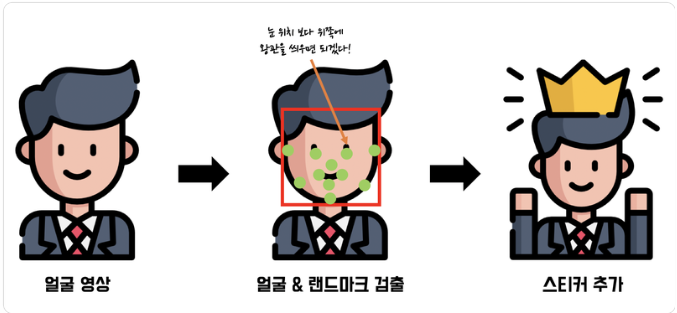


스티커를 세밀하고 자연스럽게 적용하기 위해서 눈, 코, 입, 귀와 같은 얼굴 각각의 위치를 아는 것이 중요합니다.

이 위치들을 찾아내는 기술을 랜드마크 landmark 또는 조정 alignment 이라고 합니다. 조금 더 큰 범위로는 keypoint detection 이라고 부르고 있습니다.

대부분의 face landmark 데이터셋은 눈, 코, 입과 턱을 포함하고 있습니다. 얼굴의 랜드마크를 찾아냈다면 머리의 위치를 예상하는 것은 쉽습니다. 눈과 코의 위치로부터 위로 떨어져 있는 정도를 데이터로부터 유추할 수 있을 겁니다.

따라서 우리는,

1. 얼굴이 포함된 사진을 준비하고
2. 사진으로부터 얼굴 영역 face landmark 를 찾아냅니다. (landmark를 찾기 위해서는 얼굴의 bounding box를 먼저 찾아야합니다.)
3. 찾아진 영역으로 부터 머리에 왕관 스티커를 붙여넣겠습니다.

사진 준비

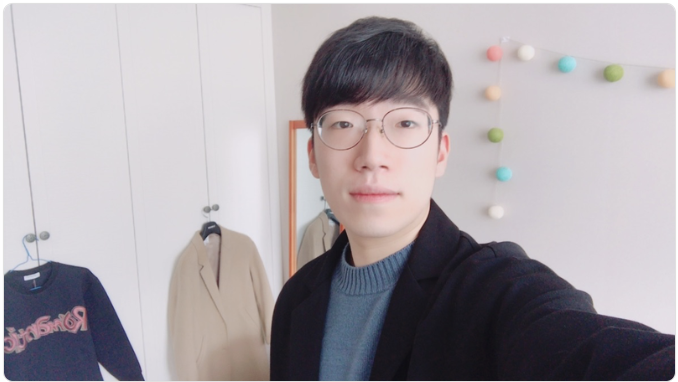

In [ ]:
# !mkdir -p ~/work/camera_sticker/models
# !mkdir -p ~/work/camera_sticker/images


work
├── camera_sticker
        └── models
        └── images
                └── image.png

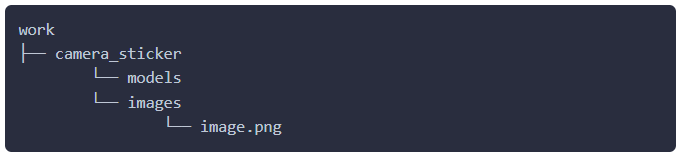

In [ ]:
# !wget https://d3s0tskafalll9.cloudfront.net/media/images/E-8-6.max-800x600_rkMHa4K.png # 기본 제공 이미지입니다. 여러분만의 이미지로 수정해보세요!
# !mv E-8-6.max-800x600_rkMHa4K.png ~/work/camera_sticker/images/image.png

여러분들의 이미지 뿐 아니라, 함께 활용할 왕관 이미지들도 미리 저장해 둡시다.

In [ ]:
# !wget https://d3s0tskafalll9.cloudfront.net/media/original_images/E-8-3.png
# !wget https://d3s0tskafalll9.cloudfront.net/media/original_images/E-8-4.png
# !mv E-8-3.png ~/work/camera_sticker/images/king.png
# !mv E-8-4.png ~/work/camera_sticker/images/hero.png

아래는 오늘 활용해야 할 이미지 처리 관련 패키지들입니다. opencv, cmake, dlib 설치가 안 돼 있다면 터미널을 열어 아래와 같이 설치해 주세요

!pip install cmake

!pip install opencv-python

!conda install -y dlib

In [ ]:
import os

!pip install cmake
!pip install opencv-python

# Install dlib using pip, as conda might not be available
# First, ensure dlib is not already installed from a previous (failed) attempt
# This might involve removing any partial installations or cached files, but for simplicity, we'll just try pip directly

# Some users might experience issues with dlib installation depending on their environment.
# For a more robust dlib installation in Colab, one might need to install build dependencies first.
# For example:
# !apt-get update
# !apt-get install -y build-essential
# !apt-get install -y libx11-dev libgtk-3-dev
# !apt-get install -y libatlas-base-dev
# !apt-get install -y gfortran

!pip install dlib

In [ ]:
# This cell is no longer needed as dlib will be installed via pip in the previous cell.

In [ ]:
# Download the dlib facial landmark model
!rm -f ~/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2
!rm -f ~/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!bunzip2 ~/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2

--2026-02-06 02:34:51--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-02-06 02:34:51--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  43.9MB/s    in 1.4s    

2026-02-06 02:34:53 (43.9 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [1]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리
print("🌫🛸")

🌫🛸


이미지 처리를 위해 opencv와 노트북에 이미지를 출력하기 위한 mtplotlib를 읽어옵니다.
준비한 이미지를 읽습니다.

In [2]:
# home_dir = os.getenv('HOME')
# my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/image.png') # 본인 이미지가 있는 경로를 가지고 온다.
# img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
# img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
# plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
# plt.show() # 이미지를 출력해준다. (실제 출력)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd '/content/drive/MyDrive/Colab Notebooks/2025.12-26.6_AIFFEL/Computer_Vision'

/content/drive/MyDrive/Colab Notebooks/2025.12-26.6_AIFFEL/Computer_Vision


In [4]:
!ls

cv01_1.ipynb  cv1.ipynb  hero.png  image.png  king.png	models


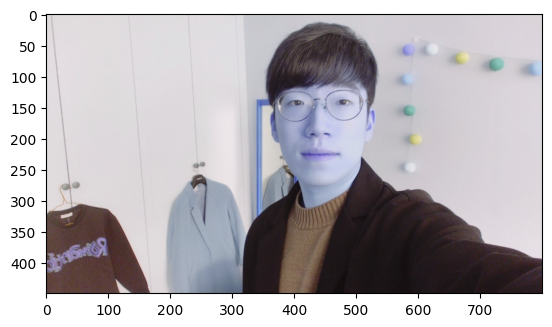

In [92]:
my_image_path = 'image.png' # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

그런데 좀 이상하지 않으신가요? 사진이 잘 나온것 같긴 한데 색상이 좀 이상합니다. 얼굴 색에 왜이렇게 푸른빛이 감도는 걸까요?

이것은 opencv의 특징 때문입니다. 오늘 사용하게 될 matplotlib, dlib 등의 이미지 라이브러리는 모두 이미지 채널을 RGB(빨강, 녹색, 파랑) 순으로 사용합니다.

그런데 opencv는 예외적으로 BGR(파랑, 녹색, 빨강)을 사용합니다. 그래서 여러분의 원본 사진에서 붉은색은 푸른색으로, 푸른색은 붉은색으로 바뀌어 출력된 것입니다. 그래서, opencv에서 다룬 이미지를 다른 이미지 라이브러리를 활용하여 출력하려면 아래와 같은 색깔 보정처리를 해주게 됩니다.

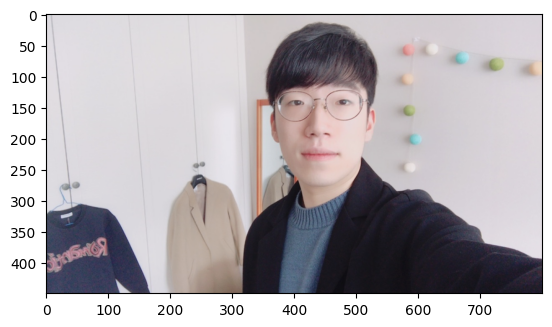

In [88]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

OpenCV : 이미지 다루기
https://opencv-python.readthedocs.io/en/latest/doc/01.imageStart/imageStart.html

# 1-3. 얼굴 검출 face detection

Object detection 기술을 이용해서 얼굴의 위치를 찾겠습니다. 이번 시간에는 빠르게 만들기 위해 학습 없이 공개되어 있는 패키지를 사용하겠습니다.

dlib의 face detector는 HOG(Histogram of Oriented Gradients)와 SVM(Support Vector Machine)을 사용해서 얼굴을 찾습니다.

HOG는 이미지에서 색상의 변화량을 나타낸 것입니다. 딥러닝이 나오기 이전에 다양하게 사용되던 방식인데요. 이미지에서 단순히 색상값만 가지고 할 수 있는 일이 제한적이었기 때문에 색상의 변화량을 계산한 HOG는 굉장히 큰 도움이 되었습니다. 이미지로부터 물체의 특징만 잘 잡아내는 능력을 갖출 수 있었거든요. 2000년대 초반에도 얼굴을 인식해 카메라 초점을 잡는 기능 등에는 모두 이 방식이 응용되었습니다.

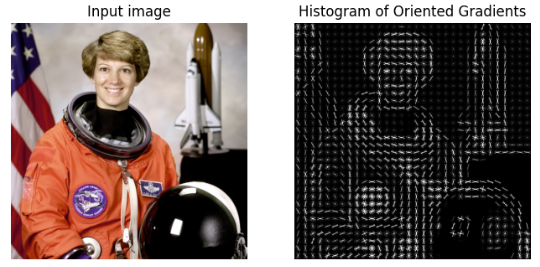

https://scikit-image.org/docs/dev/auto_examples/features_detection/plot_hog.html

HOG를 시각화한 이미지에서 사람의 형체가 잘 보이시나요?

SVM은 선형 분류기입니다. 한 이미지를 다차원 공간의 한 벡터라고 보면 여러 이미지는 여러 벡터가 될텐데요. 이 여러 벡터를 잘 구분짓는 방법입니다. 여기서는 얼굴이냐 아니냐를 구분하는 것이 중요하겠죠.

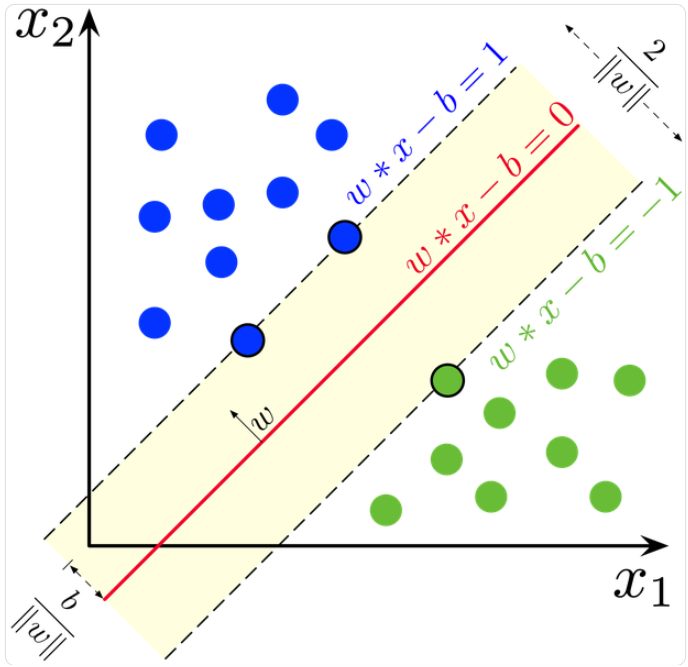

https://en.wikipedia.org/wiki/Support-vector_machine

이미지의 색상만 가지고는 SVM이 큰 힘을 발휘하지 못합니다. 하지만 이미지가 HOG를 통해 벡터로 만들어진다면 SVM이 잘 작동합니다.

그렇다면 얼굴의 위치는 어떻게 찾을 수 있을까요? 바로 sliding window를 사용합니다. sliding window는 작은 영역(window)을 이동해가며 확인하는 방법을 말합니다. 큰 이미지의 작은 영역을 잘라 얼굴이 있는지 확인하고, 다시 작은 영역을 옆으로 옮겨 얼굴이 있는지 확인하는 방식이겠네요. 물론 이렇게 한다면 이미지가 크면 클수록 오래걸리는 단점이 있습니다. 바로 이 지점이 딥러닝이 필요해지는 이유이기도 하지요.

그럼 dlib을 활용해 hog detector를 선언해 보겠습니다.

In [31]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

🌫🛸


In [71]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
print("🌫🛸")

🌫🛸


dlib은 rgb 이미지를 입력으로 받기 때문에 cvtColor() 를 이용해서 opencv 의 bgr 이미지를 rgb로 변환해 주었습니다.

detector_hog의 두 번째 파라미터는 이미지 피라미드의 수입니다. 이미지를 upsampling 방법을 통해 크기를 키우는 것을 이미지 피라미드라고 합니다. 이미지 피라미드에서 얼굴을 다시 검출하면 작게 촬영된 얼굴을 크게 볼 수 있기 때문에 더 정확한 검출이 가능합니다. 이미지 피라미드에 대한 내용은 아래 링크를 참고해 주세요.

Image Pyramids
https://opencv-python.readthedocs.io/en/latest/doc/14.imagePyramid/imagePyramid.html


➰ upsampling이란,
간단하게 데이터의 크기를 키우는 것입니다. 일반적으로 CNN의 레이어를 통과하면서 이미지의 크기를 줄이는 것을 down sampling이라고 하는데, down sampling의 반대 개념이 upsampling인 셈이죠.



찾은 얼굴을 화면에 출력해보겠습니다.

rectangles[[(345, 98) (531, 284)]]


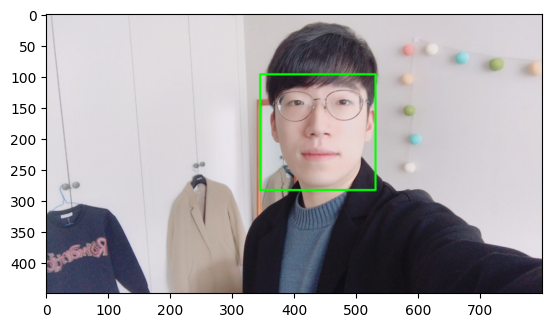

In [72]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

dlib detector 는 dlib.rectangles 타입의 객체를 반환합니다. dlib.rectangles 는 dlib.rectangle 객체의 배열 형태로 이루어져 있습니다.

dlib.rectangle객체는 left(), top(), right(), bottom(), height(), width() 등의 멤버 함수를 포함하고 있습니다. 더 자세한 정보는 dlib docs를 참고해주세요.

dlib.rectangles
https://dlib.net/python/index.html#dlib.rectangles

# 4. 얼굴 랜드마크 face landmark

앞서 말씀 드린 것처럼 스티커를 섬세하게 적용하기 위해서는 이목구비의 위치를 아는 것이 중요합니다. 이목구비의 위치를 추론하는 것을 face landmark localization 기술이라고 합니다. face landmark는 detection 의 결과물인 bounding box 로 잘라낸(crop) 얼굴 이미지를 이용합니다.

## Object keypoint estimation 알고리즘
Face landmark와 같이 객체 내부의 점을 찾는 기술을 object keypoint estimation이라고 합니다. keypoint를 찾는 알고리즘은 크게 2가지로 나누어 집니다.


1. top-down : bounding box를 찾고 box 내부의 keypoint를 예측
2. bottom-up : 이미지 전체의 keypoint를 먼저 찾고 point 관계를 이용해 군집화 해서 box 생성

이번 예제에서는 1번 방식을 다룹니다.

Dlib landmark localization

잘라진 얼굴 이미지에서 아래 68개의 이목구비 위치를 찾습니다.

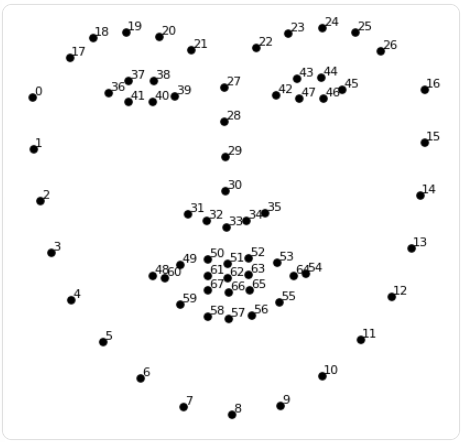

[Dlib에 사용 되는 랜드마크 순서]

이 때 점의 개수는 데이터셋과 논문마다 다릅니다. 예를 들면, AFLW 데이터셋은 21개를 사용하고 ibug 300w 데이터셋은 68개를 사용합니다.


Database	# landmarked imgs	# landmarks	# subjects	image size	image color	Ref.
Caltech 10,000 Web Faces	10,524	-	-	-	color	[1]
CMU/VASC Frontal	734	6	-	-	grayscale	[10]
CMU/VASC Profile	590	6 to 9	-	-	grayscale	[11]
IMM	240	58	40	640x480	color/grayscale	[9]
MUG	401	80	26	896x896	color	[8]
AR Purdue	508	22	116	768x576	color	[5]
BioID	1,521	20	23	384x286	grayscale	[3]
XM2VTS	2,360	68	295	720x576	color	[6]
BUHMAP-DB	2,880	52	4	640x480	color	[2]
MUCT	3,755	76	276	480x640	color	[7]
PUT	9,971	30	100	2048x1536	color	[4]
AFLW	25,993	21	-	-	color

[Landmark 데이터셋 요약]

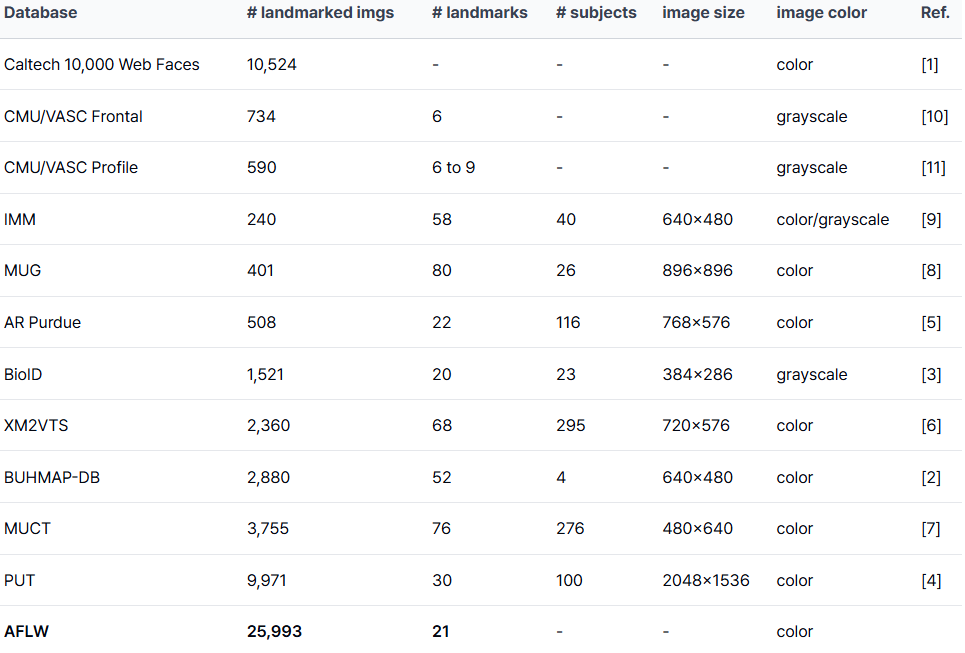

[Landmark 데이터셋 요약]

[Landmark 데이터셋 요약]

AFLW dataset
https://www.tugraz.at/institute/icg/research/team-bischof/lrs/downloads/aflw/

위 사이트 접속이 안되서 아래 참고:
Annotated Facial Landmarks in the Wild (AFLW)
https://www.tugraz.at/institute/icg/research/team-bischof/learning-recognition-surveillance/downloads/aflw

Dlib은 ibug 300-W 데이터셋으로 학습한 pretrained model 을 제공합니다. 학습 알고리즘은 regression tree의 앙상블 모델을 사용 했습니다. 자세한 내용이 궁금하신 분들은 2014년 CVPR (Computer Vision and Pattern Recognition) 에 발표한 논문One Millisecond Face Alignment with an Ensemble of Regression Trees 을 참고해 주세요. 오늘은 알고리즘을 이해하지 않아도 괜찮습니다.

300-W 데이터셋
https://ibug.doc.ic.ac.uk/resources/facial-point-annotations/

One Millisecond Face Alignment with an Ensemble of Regression Trees
https://www.cv-foundation.org/openaccess/content_cvpr_2014/papers/Kazemi_One_Millisecond_Face_2014_CVPR_paper.pdf


Dlib의 제공되는 모델을 사용해보겠습니다. 먼저 공개되어 있는 weight file을 다운로드 받습니다. 해당 모델파일은 bz2 압축파일 형태로 제공되어 압축을 풀어준 후 사용하겠습니다.

$ wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2

$ mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models

$ cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

In [ ]:
# !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
# !mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
# !cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

In [ ]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2

--2026-02-06 03:15:24--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-02-06 03:15:24--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  35.8MB/s    in 1.7s    

2026-02-06 03:15:26 (35.8 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [ ]:
!mv shape_predictor_68_face_landmarks.dat.bz2 ./models

In [ ]:
!cd .

In [ ]:
!bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

저장한 landmark 모델을 불러옵니다.

In [ ]:
# model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
#     # 저장한 landmark 모델의 주소를 model_path 변수에 저장
# landmark_predictor = dlib.shape_predictor(model_path)
#     # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
#     # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
#     # dlib.rectangle: 내부를 예측하는 박스
#     # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
# print("🌫🛸")

In [73]:
model_path = 'models/shape_predictor_68_face_landmarks.dat'
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


landmark_predictor 는 RGB 이미지와 dlib.rectangle을 입력 받아 dlib.full_object_detection 를 반환합니다.

In [74]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


points 는 dlib.full_object_detection 의 객체이기 때문에 parts() 함수로 개별 위치에 접근할 수 있습니다. 조금 더 직관적인 (x, y) 형태로 접근할 수 있도록 변환해 주었습니다. 따라서 list_points 는 tuple (x, y) 68개로 이루어진 리스트가 됩니다. 이미지에서 찾아진 얼굴 개수마다 반복하면 list_landmark에 68개의 랜드마크가 얼굴 개수만큼 저장됩니다.

랜드마크를 영상에 출력해 보겠습니다.

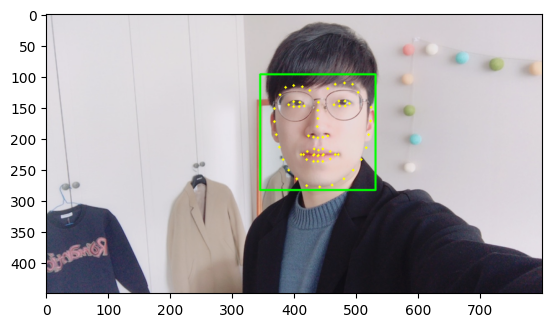

In [75]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()

# 5. 스티커 적용하기

이제 왕관 스티커를 머리에 씌울 준비가 되었습니다.

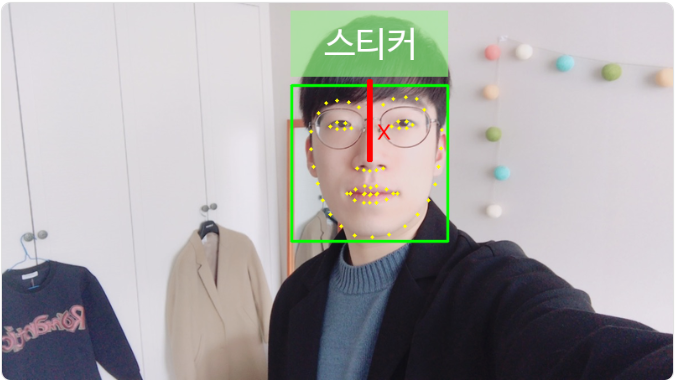

랜드마크를 기준으로 '눈썹 위 얼굴 중앙' 에 스티커를 씌우면 될 것 같습니다. 구현 방법은 여러 가지가 있습니다. 위 그림처럼 코 중심을 기준으로 높이 x 이상에 그려도 되고 눈썹 위 n 픽셀 위에 스티커를 구현해도 됩니다.

중요한 것은 얼굴 위치, 카메라의 거리에 따라 픽셀 x 가 다르기 때문에 비율로 계산을 해줘야 합니다. 계산할 수치는 두 가지 입니다.

1. 스티커 위치
 $x = x_{nose}$,  $y = y_{nose} - \frac{height}{2}$

2. 스티커 크기 $width = height = width_{bbox}$


좌표를 먼저 확인해 보겠습니다.

In [76]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# → rectangles[[(345, 98) (531, 284)]]
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
# → [[(368, 153), (368, 174), (371, 195), (376, 215), (382, 235), (391, 252), (404, 266), (420, 277), (441, 279), (461, 276), (480, 266), (495, 252), (508, 235), (516, 216), (520, 195), (523, 173), (524, 151), (377, 131), (386, 119), (399, 116), (413, 118), (425, 124), (454, 121), (466, 114), (481, 112), (494, 114), (503, 127), (439, 143), (438, 156), (438, 169), (437, 182), (423, 197), (431, 199), (438, 200), (446, 199), (454, 197), (391, 147), (399, 142), (409, 143), (416, 149), (408, 150), (399, 150), (464, 147), (472, 141), (482, 141), (489, 145), (482, 149), (473, 149), (411, 227), (421, 222), (432, 218), (439, 220), (446, 218), (458, 222), (471, 227), (458, 234), (446, 238), (438, 238), (431, 238), (420, 235), (415, 227), (432, 227), (439, 228), (447, 227), (466, 227), (446, 228), (438, 229), (431, 228)]]

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1] - dlib_rect.height()//2
        # 이미지에서 코 부위의 y값 - 얼굴 영역의 세로를 차지하는 픽셀의 수//2 → (437, 182-(186+1//2))
    w = h = dlib_rect.width()
        # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(437, 182)
(x,y) : (437,89)
(w,h) : (187,187)


제 얼굴 이미지에서는 코의 중심점이 (437, 182) 로 나오네요

준비해 둔 스티커 이미지를 읽어서 적용해 보겠습니다.

In [15]:
# sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png') # 왕관 이미지의 경로
# img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환
# img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
# print (img_sticker.shape) # 사이즈를 조정한 왕관 이미지의 차원 확인

In [77]:
sticker_path = 'king.png' # 왕관 이미지의 경로
img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape) # 사이즈를 조정한 왕관 이미지의 차원 확인

(187, 187, 3)


원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정합니다. 이미지 시작점은 top-left 좌표이기 때문입니다.

In [78]:
# x,y,w,h 모두 위에서 반복문 안에서 지정해준 값임
# x는 이미지에서 코 부위의 x값 = 437
# y는 이미지에서 코 부위의 y값 = 89
# w는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
# h는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
refined_x = x - w // 2 # 437 - (187//2) = 437-93 = 344
refined_y = y - h # 89-187 = -98
# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정합니다. 이미지 시작점은 top-left 좌표이기 때문입니다.
# 즉, refined_x, refined_y값에서 왕관 이미지가 시작됨
print (f'(x,y) : ({refined_x},{refined_y})') # 음수 발생 : 이미지 범위를 벗어남
# 우리는 현재 이마 자리에 왕관을 두고 싶은건데, 이마위치 - 왕관 높이를 했더니 이미지의 범위를 초과하여 음수가 나오는 것
# opencv는 ndarray데이터를 사용하는데, ndarray는 음수인덱스에 접근 불가하므로 스티커 이미지를 잘라 줘야 한다.

(x,y) : (344,-98)


출력해보면 문제가 생기는 것을 확인할 수 있습니다. y축 좌표의 값이 음수가 계산되었습니다.

음수는 무슨 의미일까요?

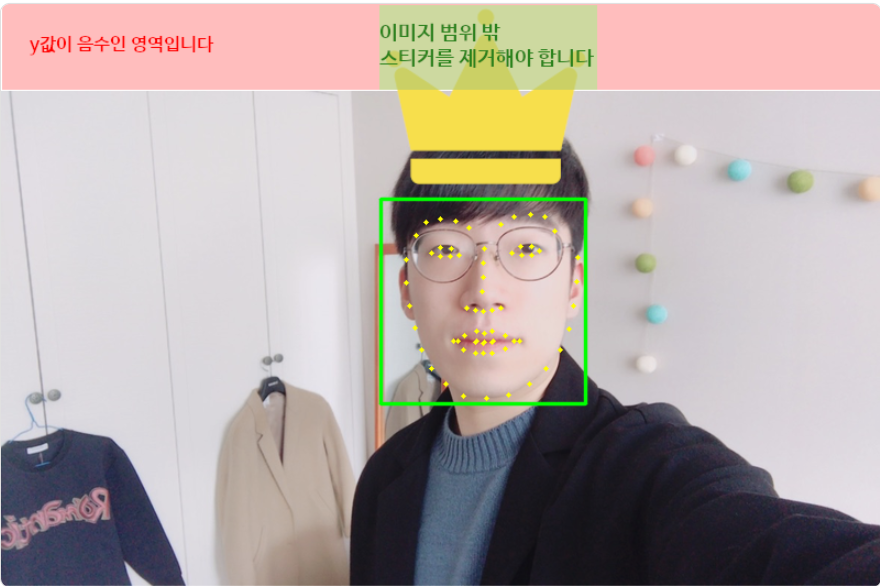

스티커의 시작점이 얼굴 사진의 영역을 벗어나면 음수로 표현됩니다. 그런데 opencv 데이터는 numpy ndarray 형태의 데이터를 사용합니다. ndarray는 음수 인덱스에 접근할 수 없기 때문에 음수에 대한 예외 처리를 해줘야 합니다. 따라서 그림에서 보시는 것처럼 원본 이미지의 범위를 벗어난 스티커 부분을 제거해 주어야 합니다.

위의 경우에서는 y축 좌표의 값만 음수로 나왔지만 x축 좌표의 값도 음수로 나올 수 있겠죠?

사실 스티커가 원본 이미지의 범위를 넘어가는 경우는 하나 더 있습니다. 바로 스티커의 시작점 + 스티커 사진의 크기가 원본 이미지의 크기보다 큰 경우입니다. 스티커 사진의 오른쪽이나 아래쪽으로 넘어가는 경우죠. 이 경우는 어떻게 처리해야 하는지 생각해보세요.

In [79]:
# 왕관 이미지가 이미지 밖에서 시작하지 않도록 조정이 필요함
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# 현재 상황에서는 -y 크기만큼 스티커를 crop 하고, top 의 x좌표와 y 좌표를 각각의 경우에 맞춰 원본 이미지의 경계 값으로 수정하면 아래와 같은 형식으로 나옵니다.
# 음수값 만큼 왕관 이미지(혹은 추후 적용할 스티커 이미지)를 자른다.
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
# 왕관 이미지를 씌우기 위해 왕관 이미지가 시작할 y좌표 값 조정
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
    refined_y = 0

print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (344,0)


-y 크기만큼 스티커를 crop 하고, top 의 x좌표와 y 좌표를 각각의 경우에 맞춰 원본 이미지의 경계 값으로 수정하면 아래와 같은 형식으로 나옵니다.

In [80]:
# sticker_area는 원본이미지에서 스티커를 적용할 위치를 crop한 이미지 입니다.
# 예제에서는 (344,0) 부터 (344+187, 0+89) 범위의 이미지를 의미합니다.
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_show[0:0+89, 344:344+187]
# img_show[0:89, 344:531]
# 즉, x좌표는 344~531 / y좌표는 0~89가 됨
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 왕관 이미지에서 사용할 부분은 0이 아닌 색이 있는 부분을 사용합니다.
# 왕관 이미지에서 0이 나오는 부분은 흰색이라는 뜻, 즉 이미지가 없다는 소리임.
# 현재 왕관 이미지에서는 왕관과 받침대 밑의 ------ 부분이 됨
# 그렇기 때문에 0인 부분(이미지가 없는 부분)은 제외하고 적용
# sticker_area는 원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지입니다.
# 즉, 왕관 이미지에서 왕관 이미지가 없는 부분(왕관과 받침대 밑의 ------ 부분)은 원본 이미지에서 미리 잘라놓은 sticker_area(스티커 적용할 부분 만큼 원본 이미지에서 자른 이미지)를 적용하고,
# 나머지 부분은 스티커로 채워주면 됨
# np.where는 조건에 해당하는 인덱스만 찾아서 값을 적용하는 방법이다.
# 아래 코드에서는 img_sticker가 0일 경우(왕관 이미지에서 왕관 부분 제외한 나머지 이미지)에는 sticker_area(원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지)를 적용하고,
# 나머지 부분은 img_sticker(왕관 이미지)를 적용한다.
img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
print("슝~")

슝~


sticker_area는 원본이미지에서 스티커를 적용할 위치를 crop한 이미지 입니다. 예제에서는 (344,0) 부터 (344+187, 0+89) 범위의 이미지를 의미합니다.

스티커 이미지에서 사용할 부분은 0 이 아닌 색이 있는 부분을 사용합니다. 따라서 np.where를 통해 img_sticker 가 0 인 부분은 sticker_area를 사용하고 0이 아닌 부분을 img_sticker를 사용하시면 됩니다. img_show 에 다시 적용하겠습니다.

결과 이미지를 출력하면,

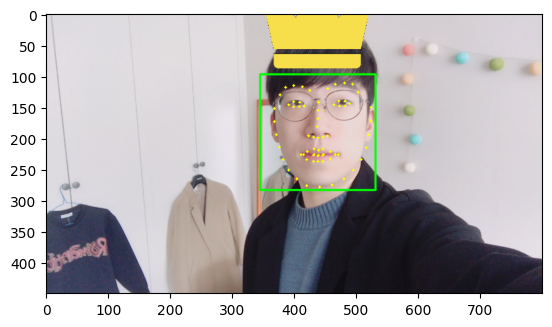

In [81]:
# 왕관 이미지를 적용한 이미지를 보여준다.
# 얼굴 영역(7-3)과 랜드마크(7-4)를 미리 적용해놓은 img_show에 왕관 이미지를 덧붙인 이미지가 나오게 된다.)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

짠~ 스티커 기본 기능이 완성 되었습니다.

bounding box와 landmark를 제거하고 최종 결과만 출력해 봅시다. img_show 대신, 지금까지 아껴 두었던 img_bgr을 활용할 것입니다.

In [93]:
# 아래 작업(스티커 아래 이미지도 흐릿하게 보이도록) 을 위해 이미지 별도 저장

img_bgr2 = img_bgr.copy()
img_sticker2 = img_sticker.copy()


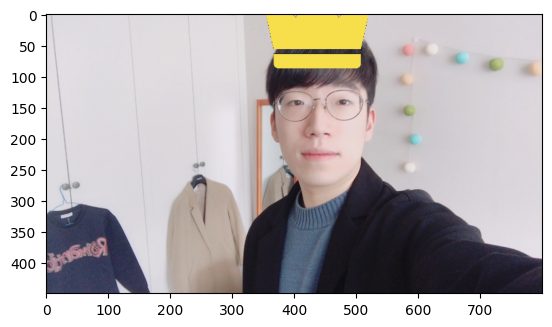

In [85]:
# 위에서 설명했으므로 생략
# 왕관 이미지
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_bgr은 7-2에서 rgb로만 적용해놓은 원본 이미지이다.
img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)) # rgb만 적용해놓은 원본 이미지에 왕관 이미지를 덮어 씌운 이미지가 나오게 된다.
plt.show()

여러분이 사용하고 있는 어플의 초기 버전을 완성했습니다

## 스티커 아래 이미지도 흐릿하게 보이도록

### cv2.addWeighted()

기본적인 사용법:

cv2.addWeighted(src1, alpha, src2, beta, gamma[, dst[, dtype]]) → dst
각 인자에 대한 설명은 다음과 같습니다:

- src1: 첫 번째 입력 이미지입니다.
- alpha: 첫 번째 이미지 src1에 적용할 가중치입니다. 이 값은 보통 0에서 1 사이입니다.
- src2: 두 번째 입력 이미지입니다. src1과 동일한 크기와 타입이어야 합니다.
- beta: 두 번째 이미지 src2에 적용할 가중치입니다. 이 값도 보통 0에서 1 사이이며, alpha + beta = 1이 되는 경우가 많습니다.
- gamma: 결과 이미지에 더해질 상수 값입니다. 보통 0으로 설정됩니다.
- dst: (선택 사항) 출력 이미지를 저장할 배열입니다.
- dtype: (선택 사항) 출력 이미지의 깊이(depth)입니다.

결과 이미지는 dst = src1 * alpha + src2 * beta + gamma 공식에 따라 계산됩니다.

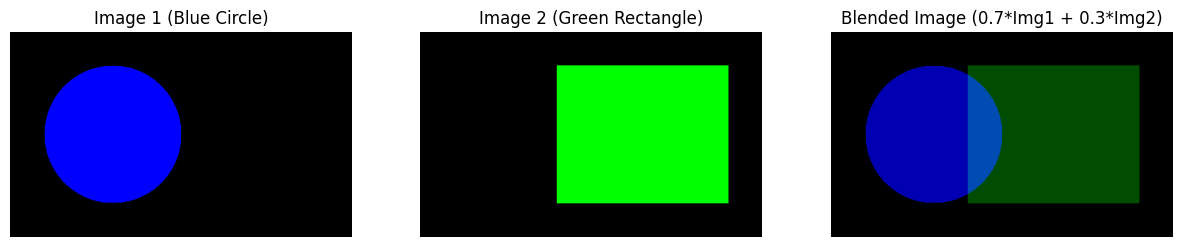

In [23]:
# cv2.addWeighted()를 사용하여 두 이미지를 블렌딩하는 예제 코드

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 예제 이미지 생성 (임의의 이미지로 대체 가능)
# 여기서는 간단하게 두 개의 그레이스케일 이미지를 생성합니다.
img1 = np.zeros((300, 500, 3), dtype=np.uint8)
img1 = cv2.circle(img1, (150, 150), 100, (255, 0, 0), -1) # 파란색 원

img2 = np.zeros((300, 500, 3), dtype=np.uint8)
img2 = cv2.rectangle(img2, (200, 50), (450, 250), (0, 255, 0), -1) # 녹색 사각형

# 이미지 합치기
# alpha=0.7, beta=0.3, gamma=0 (기본값)
blended_img = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)

# 결과 출력
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title('Image 1 (Blue Circle)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title('Image 2 (Green Rectangle)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(blended_img, cv2.COLOR_BGR2RGB))
plt.title('Blended Image (0.7*Img1 + 0.3*Img2)')
plt.axis('off')

plt.show()


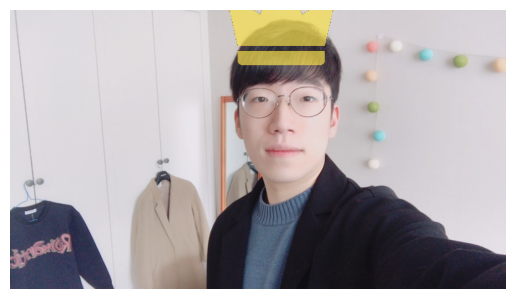

In [94]:
# 왕관이 들어갈 영역
sticker_area = img_bgr2[
    refined_y:refined_y + img_sticker.shape[0],
    refined_x:refined_x + img_sticker.shape[1]
]

alpha = 0.7
beta = 1 - alpha

# 1️⃣ 검정 배경 제외 마스크 (H, W)
mask = np.any(img_sticker != [0, 0, 0], axis=2)

# 2️⃣ 전체 블렌딩
blended = cv2.addWeighted(
    sticker_area, beta,
    img_sticker2, alpha,
    0
)

# 3️⃣ 왕관 부분만 적용 (배경은 그대로!)
sticker_area[mask] = blended[mask]

# 4️⃣ 원본 이미지에 반영
img_bgr2[
    refined_y:refined_y + img_sticker.shape[0],
    refined_x:refined_x + img_sticker.shape[1]
] = sticker_area.astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
